# Pipeline 5: Resident Intervention Recommender

## 1. Problem Framing

**Business question:** Which intervention category should social workers prioritize next for each resident to maximize wellbeing improvement and prevent incidents?

**Who cares:** Social workers and safehouse managers. Staff bandwidth is limited — there are only a handful of social workers managing 60+ cases across 9 safehouses. Each month they must decide whether to focus a resident's plan on Safety, Psychosocial support, Education, Physical Health, or Reintegration. Currently these decisions rely entirely on individual judgment with no systematic data support.

**Why it matters:** A wrong prioritization can mean a girl who needed a safety intervention instead receives only educational support, potentially missing early warning signs of an incident. Conversely, over-allocating safety resources to stable residents means fewer sessions for those who truly need them.

**Two modeling goals — we do both:**

**Explanatory model (OLS regression):** We want to understand *which intervention categories and resident characteristics are most associated with wellbeing improvement*. This uses OLS with interpretable coefficients so the organization can reason about *why* certain interventions matter and design better programs.

**Predictive model (Random Forest / Gradient Boosting):** We want to accurately predict next-month wellbeing change and incident risk using all available data. This powers the operational recommendation engine that scores each resident monthly.

**Why both:** The explanatory model answers "what types of interventions are associated with the best outcomes?" The predictive model answers "what should we recommend for *this specific resident* right now?" These are complementary but require different modeling choices.

**Target variables:**
- **Primary (continuous):** `wellbeing_delta` — composite next-period change in education progress and health score, computed month-over-month from `education_records` and `health_wellbeing_records`.
- **Secondary (binary):** `incident_next_30d` — did the resident have any incident in the following month? Built from `incident_reports`.

**Success metrics:**
- Regression: R², MAE, RMSE on held-out test data; comparison to a predict-the-mean baseline.
- Classification: ROC-AUC and recall for the incident class (false negatives are costly — missing a resident who will have an incident).

**Critical error consideration:** A false negative on incident prediction (predicting "no incident" when one occurs) is the most dangerous error. We weight evaluation to surface this risk.

## 2. Data Acquisition, Preparation & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             precision_recall_curve, f1_score)
from sklearn.inspection import permutation_importance
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import json, os
from db_loader import load_table

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

residents      = load_table('Residents')
education      = load_table('EducationRecords')
health         = load_table('HealthWellbeingRecords')
interventions  = load_table('InterventionPlans')
incidents      = load_table('IncidentReports')
recordings     = load_table('ProcessRecordings')
visitations    = load_table('HomeVisitations')

print('Table shapes:')
for name, df in [('residents', residents), ('education', education),
                  ('health', health), ('interventions', interventions),
                  ('incidents', incidents), ('recordings', recordings),
                  ('visitations', visitations)]:
    print(f'  {name:15s}: {df.shape}')

Table shapes:
  residents      : (60, 49)
  education      : (534, 10)
  health         : (534, 14)
  interventions  : (180, 11)
  incidents      : (100, 12)
  recordings     : (2819, 14)
  visitations    : (1337, 14)


### 2.1 Parse dates and build month keys

We align all tables to a common **resident-month** grain. Education and health records already have one row per resident per month; we aggregate the other tables into the same windows.

In [2]:
education['record_date'] = pd.to_datetime(education['record_date'])
health['record_date']    = pd.to_datetime(health['record_date'])
incidents['incident_date']  = pd.to_datetime(incidents['incident_date'])
recordings['session_date']  = pd.to_datetime(recordings['session_date'])
visitations['visit_date']   = pd.to_datetime(visitations['visit_date'])
interventions['created_at'] = pd.to_datetime(interventions['created_at'])
interventions['updated_at'] = pd.to_datetime(interventions['updated_at'])
residents['date_of_admission'] = pd.to_datetime(residents['date_of_admission'])

education['month']   = education['record_date'].dt.to_period('M')
health['month']      = health['record_date'].dt.to_period('M')

month_grid = education[['resident_id', 'month']].drop_duplicates().sort_values(['resident_id', 'month'])
print(f'Resident-month rows: {len(month_grid)}')
print(f'Unique residents: {month_grid["resident_id"].nunique()}')
print(f'Month range: {month_grid["month"].min()} to {month_grid["month"].max()}')

Resident-month rows: 534
Unique residents: 60
Month range: 2023-01 to 2026-02


### 2.2 Build the resident-month feature frame

We join education, health, counseling session aggregates, visitation aggregates, intervention state, and incident history into a single row per resident per month.

In [3]:
# --- Education features (monthly) ---
edu_features = education.merge(month_grid, on=['resident_id', 'month'], how='inner')[[
    'resident_id', 'month', 'attendance_rate', 'progress_percent'
]]

# --- Health features (monthly) ---
health_features = health.merge(month_grid, on=['resident_id', 'month'], how='inner')[[
    'resident_id', 'month', 'general_health_score', 'nutrition_score',
    'sleep_quality_score', 'energy_level_score', 'bmi',
    'medical_checkup_done', 'dental_checkup_done', 'psychological_checkup_done'
]]

# --- Process recording aggregates (rolling 30-day window) ---
def agg_recordings_for_month(rid, month_period):
    month_start = month_period.start_time
    month_end = month_period.end_time
    mask = (recordings['resident_id'] == rid) & \
           (recordings['session_date'] >= month_start - pd.Timedelta(days=30)) & \
           (recordings['session_date'] <= month_end)
    sub = recordings.loc[mask]
    if len(sub) == 0:
        return pd.Series({
            'session_count_30d': 0, 'pct_progress_noted': 0.0,
            'pct_concerns_flagged': 0.0, 'avg_session_duration': 0.0
        })
    return pd.Series({
        'session_count_30d': len(sub),
        'pct_progress_noted': sub['progress_noted'].mean(),
        'pct_concerns_flagged': sub['concerns_flagged'].mean(),
        'avg_session_duration': sub['session_duration_minutes'].mean()
    })

# --- Home visitation aggregates (rolling 90-day window) ---
def agg_visitations_for_month(rid, month_period):
    month_end = month_period.end_time
    month_start = month_period.start_time
    mask = (visitations['resident_id'] == rid) & \
           (visitations['visit_date'] >= month_start - pd.Timedelta(days=90)) & \
           (visitations['visit_date'] <= month_end)
    sub = visitations.loc[mask]
    if len(sub) == 0:
        return pd.Series({
            'visit_count_90d': 0, 'pct_safety_concerns': 0.0,
            'pct_favorable_outcome': 0.0
        })
    return pd.Series({
        'visit_count_90d': len(sub),
        'pct_safety_concerns': sub['safety_concerns_noted'].mean(),
        'pct_favorable_outcome': (sub['visit_outcome'] == 'Favorable').mean()
    })

# --- Intervention state (as of that month) ---
plan_categories = ['Safety', 'Psychosocial', 'Education', 'Physical Health', 'Reintegration']

def agg_interventions_for_month(rid, month_period):
    month_end = month_period.end_time
    mask = (interventions['resident_id'] == rid) & \
           (interventions['created_at'] <= month_end)
    sub = interventions.loc[mask]
    active = sub[sub['status'].isin(['Open', 'In Progress'])]
    result = {
        'total_plans': len(sub),
        'active_plans': len(active),
        'pct_achieved': (sub['status'] == 'Achieved').mean() if len(sub) > 0 else 0.0
    }
    for cat in plan_categories:
        result[f'has_active_{cat.replace(" ", "_").lower()}'] = int(
            (active['plan_category'] == cat).any()
        )
    return pd.Series(result)

# --- Incident history (60-day lookback) ---
severity_map = {'Low': 1, 'Medium': 2, 'High': 3}

def agg_incidents_for_month(rid, month_period):
    month_end = month_period.end_time
    month_start = month_period.start_time
    mask = (incidents['resident_id'] == rid) & \
           (incidents['incident_date'] >= month_start - pd.Timedelta(days=60)) & \
           (incidents['incident_date'] <= month_end)
    sub = incidents.loc[mask]
    if len(sub) == 0:
        return pd.Series({'incident_count_60d': 0, 'max_severity_60d': 0})
    return pd.Series({
        'incident_count_60d': len(sub),
        'max_severity_60d': sub['severity'].map(severity_map).max()
    })

print('Aggregating rolling features per resident-month (this takes a moment)...')

rec_aggs = month_grid.apply(
    lambda r: agg_recordings_for_month(r['resident_id'], r['month']), axis=1)
vis_aggs = month_grid.apply(
    lambda r: agg_visitations_for_month(r['resident_id'], r['month']), axis=1)
int_aggs = month_grid.apply(
    lambda r: agg_interventions_for_month(r['resident_id'], r['month']), axis=1)
inc_aggs = month_grid.apply(
    lambda r: agg_incidents_for_month(r['resident_id'], r['month']), axis=1)

rolling_features = pd.concat([month_grid.reset_index(drop=True),
                              rec_aggs.reset_index(drop=True),
                              vis_aggs.reset_index(drop=True),
                              int_aggs.reset_index(drop=True),
                              inc_aggs.reset_index(drop=True)], axis=1)

print(f'Rolling features shape: {rolling_features.shape}')

Aggregating rolling features per resident-month (this takes a moment)...


Rolling features shape: (534, 19)


In [4]:
# --- Merge all features into one resident-month frame ---
df = rolling_features.merge(edu_features, on=['resident_id', 'month'], how='left') \
                      .merge(health_features, on=['resident_id', 'month'], how='left')

# --- Static resident features ---
static_cols = [
    'resident_id', 'safehouse_id', 'case_category', 'initial_risk_level',
    'referral_source', 'date_of_admission',
    'sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_child_labor',
    'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec',
    'sub_cat_at_risk', 'sub_cat_street_child',
    'is_pwd', 'has_special_needs',
    'family_is_4ps', 'family_solo_parent', 'family_indigenous',
    'family_parent_pwd', 'family_informal_settler'
]
df = df.merge(residents[static_cols], on='resident_id', how='left')

# Compute months since admission
df['month_start_dt'] = df['month'].dt.to_timestamp()
df['months_since_admission'] = (
    (df['month_start_dt'] - df['date_of_admission']).dt.days / 30.44
).clip(lower=0)

# Cast booleans to int
bool_cols = [c for c in df.columns if df[c].dtype == 'bool' or
             c.startswith('sub_cat_') or c.startswith('family_') or
             c in ['is_pwd', 'has_special_needs',
                    'medical_checkup_done', 'dental_checkup_done', 'psychological_checkup_done']]
for col in bool_cols:
    df[col] = df[col].astype(int) if df[col].dtype == 'bool' else pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

print(f'Combined feature frame: {df.shape}')
df.head()

Combined feature frame: (534, 51)


,resident_id,month,session_count_30d,pct_progress_noted,pct_concerns_flagged,avg_session_duration,visit_count_90d,pct_safety_concerns,pct_favorable_outcome,total_plans,...,sub_cat_street_child,is_pwd,has_special_needs,family_is_4ps,family_solo_parent,family_indigenous,family_parent_pwd,family_informal_settler,month_start_dt,months_since_admission
0,1,2023-10,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,3.0,...,0,0,1,0,0,0,0,0,2023-10-01,0.000000
1,1,2023-11,3.0,1.000000,0.666667,74.000000,2.0,0.500000,1.000000,3.0,...,0,0,1,0,0,0,0,0,2023-11-01,0.492773
2,1,2023-12,9.0,0.888889,0.222222,74.888889,7.0,0.142857,0.428571,3.0,...,0,0,1,0,0,0,0,0,2023-12-01,1.478318
3,1,2024-01,8.0,0.875000,0.125000,69.625000,9.0,0.333333,0.444444,3.0,...,0,0,1,0,0,0,0,0,2024-01-01,2.496715
4,1,2024-02,5.0,0.800000,0.200000,49.400000,9.0,0.222222,0.333333,3.0,...,0,0,1,0,0,0,0,0,2024-02-01,3.515112


### 2.3 Build target variables

**`wellbeing_delta`**: For each resident-month, compute the change in a composite score (average of normalized education progress and health score) compared to the previous month.

**`incident_next_30d`**: Binary — did this resident have an incident in the following month?

In [5]:
# Composite wellbeing score: average of z-scored education progress and health score
df['edu_z'] = (df['progress_percent'] - df['progress_percent'].mean()) / df['progress_percent'].std()
df['health_z'] = (df['general_health_score'] - df['general_health_score'].mean()) / df['general_health_score'].std()
df['wellbeing_composite'] = (df['edu_z'] + df['health_z']) / 2

# Compute month-over-month delta per resident
df = df.sort_values(['resident_id', 'month'])
df['wellbeing_delta'] = df.groupby('resident_id')['wellbeing_composite'].diff()

# Incident in the next month: for each resident-month, check if an incident occurs in month+1
def has_incident_next_month(row):
    next_month_start = (row['month'] + 1).start_time
    next_month_end = (row['month'] + 1).end_time
    mask = (incidents['resident_id'] == row['resident_id']) & \
           (incidents['incident_date'] >= next_month_start) & \
           (incidents['incident_date'] <= next_month_end)
    return int(incidents.loc[mask].shape[0] > 0)

df['incident_next_30d'] = df.apply(has_incident_next_month, axis=1)

print(f'wellbeing_delta stats:\n{df["wellbeing_delta"].describe()}\n')
print(f'incident_next_30d distribution:\n{df["incident_next_30d"].value_counts()}')

# Drop the first month per resident (no delta available)
df_model = df.dropna(subset=['wellbeing_delta']).copy()
print(f'\nRows available for modeling (after dropping first month per resident): {len(df_model)}')

wellbeing_delta stats:
count    474.000000
mean       0.197132
std        0.254428
min       -0.567614
25%        0.011717
50%        0.174549
75%        0.369167
max        0.985898
Name: wellbeing_delta, dtype: float64

incident_next_30d distribution:
incident_next_30d
0    480
1     54
Name: count, dtype: int64

Rows available for modeling (after dropping first month per resident): 474


### 2.4 Exploratory Data Analysis

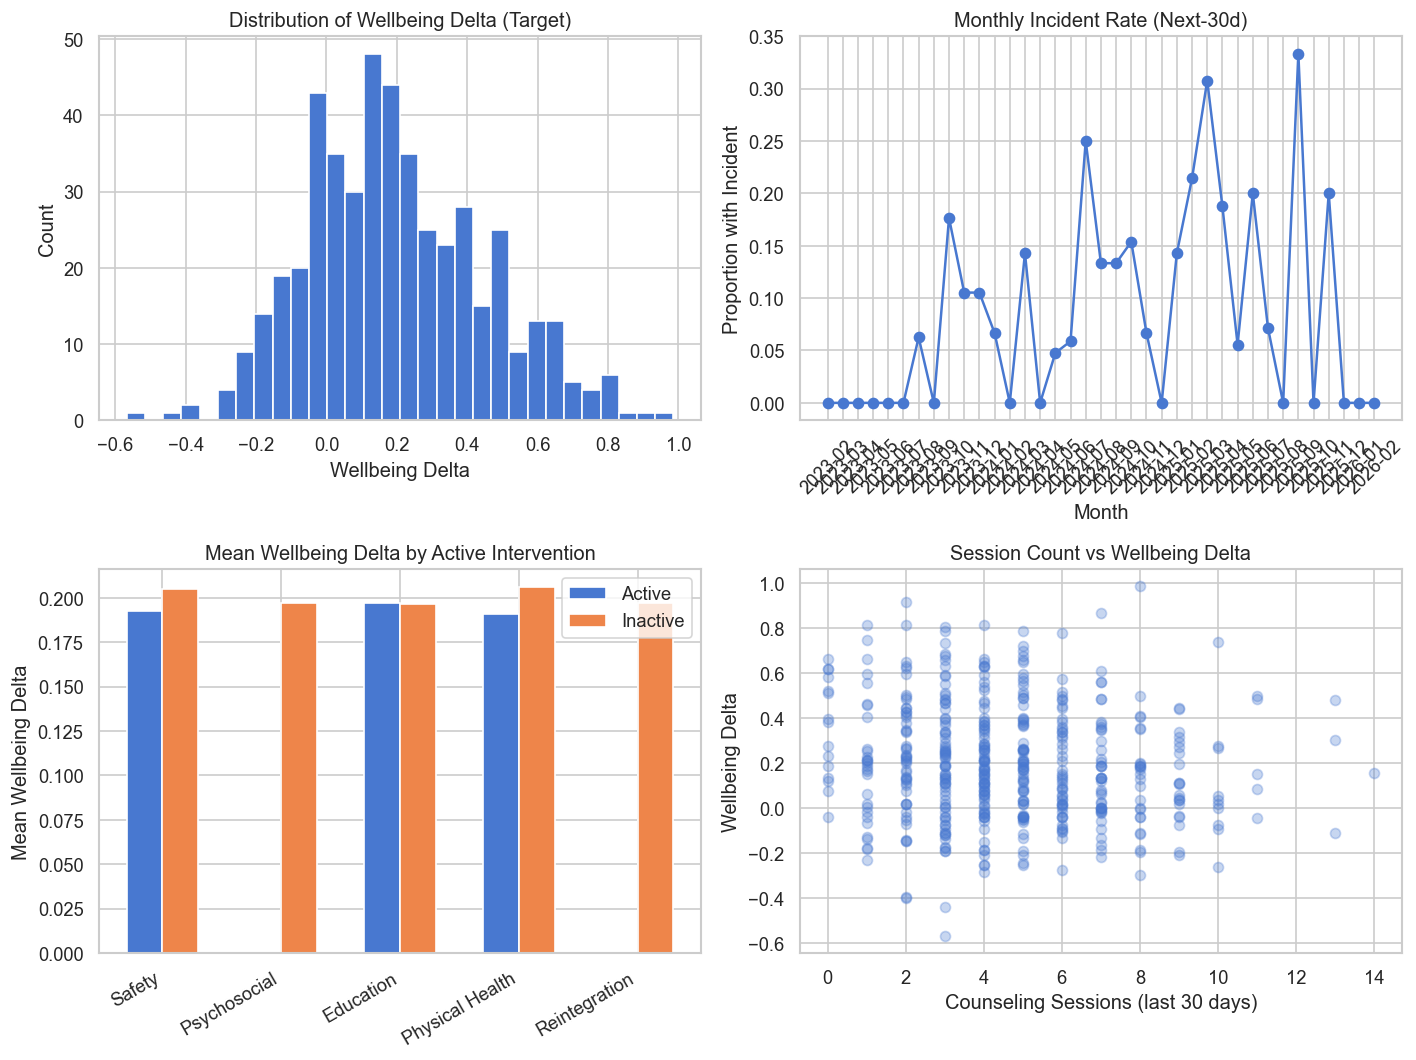

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Distribution of wellbeing delta
axes[0, 0].hist(df_model['wellbeing_delta'].dropna(), bins=30, edgecolor='white')
axes[0, 0].set_title('Distribution of Wellbeing Delta (Target)')
axes[0, 0].set_xlabel('Wellbeing Delta')
axes[0, 0].set_ylabel('Count')

# Incident rate over time
monthly_incident_rate = df_model.groupby('month')['incident_next_30d'].mean()
axes[0, 1].plot(monthly_incident_rate.index.astype(str), monthly_incident_rate.values, marker='o')
axes[0, 1].set_title('Monthly Incident Rate (Next-30d)')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Proportion with Incident')
axes[0, 1].tick_params(axis='x', rotation=45)

# Wellbeing delta by intervention category presence
intervention_cols = [c for c in df_model.columns if c.startswith('has_active_')]
deltas_by_intervention = []
for col in intervention_cols:
    label = col.replace('has_active_', '').replace('_', ' ').title()
    group_yes = df_model.loc[df_model[col] == 1, 'wellbeing_delta']
    group_no = df_model.loc[df_model[col] == 0, 'wellbeing_delta']
    deltas_by_intervention.append({'Intervention': label, 'Active': group_yes.mean(), 'Inactive': group_no.mean()})
delta_df = pd.DataFrame(deltas_by_intervention)
x = np.arange(len(delta_df))
axes[1, 0].bar(x - 0.15, delta_df['Active'], 0.3, label='Active')
axes[1, 0].bar(x + 0.15, delta_df['Inactive'], 0.3, label='Inactive')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(delta_df['Intervention'], rotation=30, ha='right')
axes[1, 0].set_title('Mean Wellbeing Delta by Active Intervention')
axes[1, 0].set_ylabel('Mean Wellbeing Delta')
axes[1, 0].legend()
axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

# Correlation of session count with wellbeing delta
axes[1, 1].scatter(df_model['session_count_30d'], df_model['wellbeing_delta'], alpha=0.3)
axes[1, 1].set_title('Session Count vs Wellbeing Delta')
axes[1, 1].set_xlabel('Counseling Sessions (last 30 days)')
axes[1, 1].set_ylabel('Wellbeing Delta')

plt.tight_layout()
plt.show()

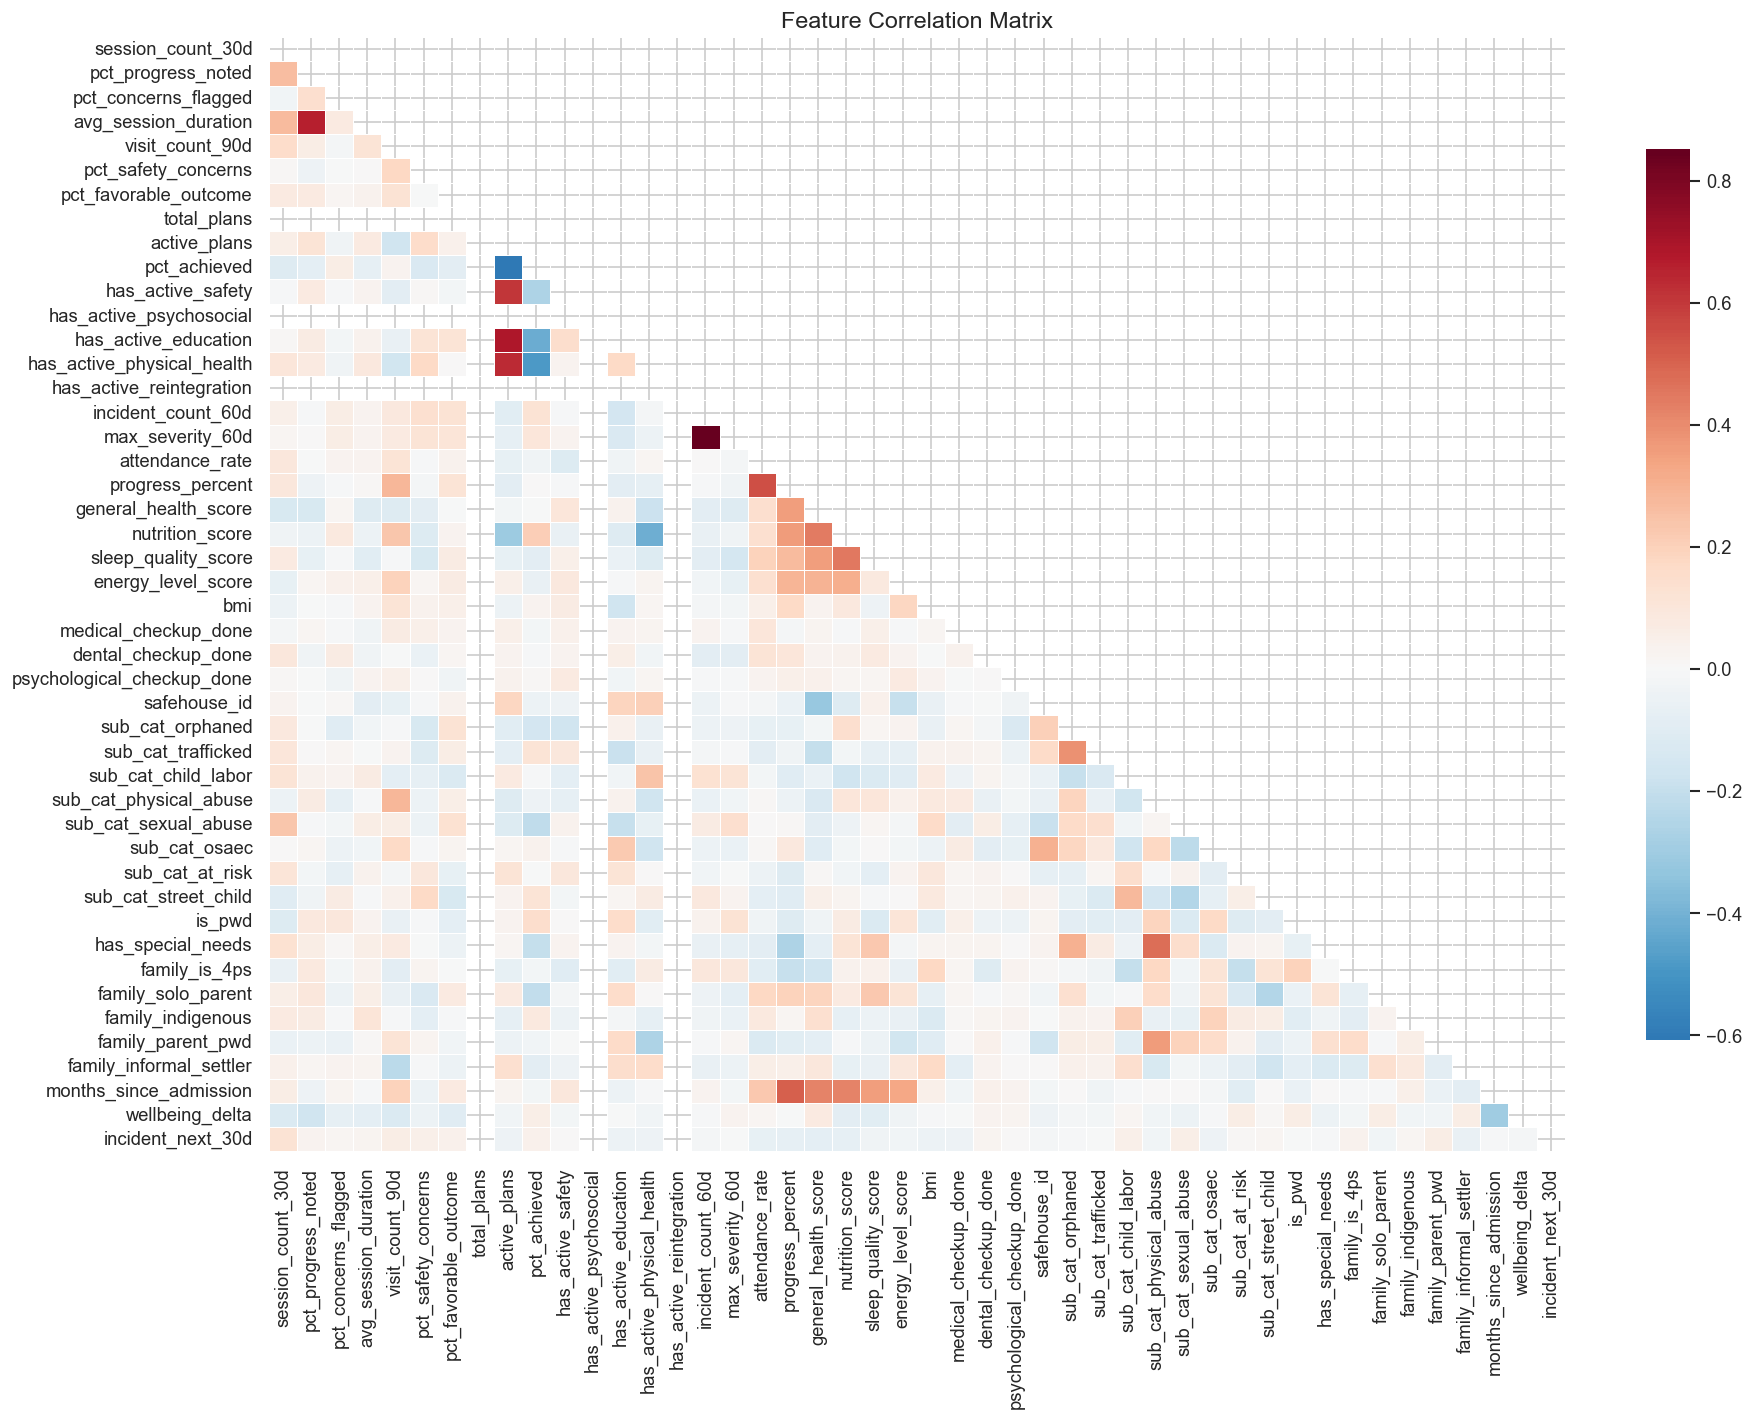

Top 10 positive correlations with wellbeing_delta:
dental_checkup_done         0.033193
pct_achieved                0.053492
sub_cat_at_risk             0.060926
is_pwd                      0.061688
family_solo_parent          0.062106
family_informal_settler     0.062431
general_health_score        0.077676
total_plans                      NaN
has_active_psychosocial          NaN
has_active_reintegration         NaN

Top 10 negative correlations with wellbeing_delta:
months_since_admission   -0.302574
pct_progress_noted       -0.174406
visit_count_90d          -0.121946
session_count_30d        -0.121313
pct_favorable_outcome    -0.103207
sleep_quality_score      -0.099622
nutrition_score          -0.088944
avg_session_duration     -0.080763
pct_concerns_flagged     -0.074012
has_special_needs        -0.051348


In [7]:
# Correlation heatmap of numeric features vs targets
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
# Remove helper columns from correlation
exclude = ['resident_id', 'edu_z', 'health_z', 'wellbeing_composite']
numeric_for_corr = [c for c in numeric_cols if c not in exclude]

corr = df_model[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, ax=ax,
            fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with the target
target_corr = corr['wellbeing_delta'].drop(['wellbeing_delta', 'incident_next_30d'], errors='ignore').sort_values()
print('Top 10 positive correlations with wellbeing_delta:')
print(target_corr.tail(10).to_string())
print('\nTop 10 negative correlations with wellbeing_delta:')
print(target_corr.head(10).to_string())

In [8]:
# Missing values summary
missing = df_model.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print('Columns with missing values:')
    print(missing.to_string())
else:
    print('No missing values in the feature frame.')

No missing values in the feature frame.


### 2.5 Prepare modeling data

We define our feature matrix and targets, identify numeric vs categorical columns, and build the sklearn preprocessing pipeline. All preprocessing is learned from training data only to prevent leakage.

In [9]:
# Define feature set (exclude targets, IDs, helper columns, PII, dates)
drop_cols = [
    'resident_id', 'month', 'month_start_dt', 'date_of_admission',
    'wellbeing_delta', 'incident_next_30d',
    'edu_z', 'health_z', 'wellbeing_composite'
]
feature_cols = [c for c in df_model.columns if c not in drop_cols]

X = df_model[feature_cols].copy()
y_reg = df_model['wellbeing_delta'].copy()
y_cls = df_model['incident_next_30d'].copy()

# Identify feature types
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f'Total features: {len(feature_cols)}')
print(f'  Numeric: {len(numeric_features)}')
print(f'  Categorical: {len(categorical_features)} — {categorical_features}')
print(f'Regression target (wellbeing_delta): {len(y_reg)} rows')
print(f'Classification target (incident_next_30d): {y_cls.value_counts().to_dict()}')

Total features: 47
  Numeric: 44
  Categorical: 3 — ['case_category', 'initial_risk_level', 'referral_source']
Regression target (wellbeing_delta): 474 rows
Classification target (incident_next_30d): {0: 428, 1: 46}


In [10]:
# Time-based split: train on earlier months, test on later months
df_model_sorted = df_model.sort_values('month')
months_sorted = df_model_sorted['month'].unique()
split_idx = int(len(months_sorted) * 0.8)
train_months = months_sorted[:split_idx]
test_months = months_sorted[split_idx:]

train_mask = df_model_sorted['month'].isin(train_months)
test_mask = df_model_sorted['month'].isin(test_months)

X_train = df_model_sorted.loc[train_mask, feature_cols].copy()
X_test  = df_model_sorted.loc[test_mask, feature_cols].copy()
y_train_reg = df_model_sorted.loc[train_mask, 'wellbeing_delta'].copy()
y_test_reg  = df_model_sorted.loc[test_mask, 'wellbeing_delta'].copy()
y_train_cls = df_model_sorted.loc[train_mask, 'incident_next_30d'].copy()
y_test_cls  = df_model_sorted.loc[test_mask, 'incident_next_30d'].copy()

print(f'Train months: {train_months[0]} to {train_months[-1]} ({len(X_train)} rows)')
print(f'Test months:  {test_months[0]} to {test_months[-1]} ({len(X_test)} rows)')
print(f'Train incident rate: {y_train_cls.mean():.3f}')
print(f'Test incident rate:  {y_test_cls.mean():.3f}')

Train months: 2023-02 to 2025-06 (423 rows)
Test months:  2025-07 to 2026-02 (51 rows)
Train incident rate: 0.097
Test incident rate:  0.098


In [11]:
# Build sklearn preprocessing pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Fit on training data only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

feature_names_out = (numeric_features +
    list(preprocessor.named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_features)))

print(f'Processed training shape: {X_train_processed.shape}')
print(f'Processed test shape:     {X_test_processed.shape}')
print(f'Total encoded features:   {len(feature_names_out)}')

Processed training shape: (423, 55)
Processed test shape:     (51, 55)
Total encoded features:   55


## 3. Modeling & Feature Selection

### 3.1 Explanatory Model — OLS Regression

We use OLS regression to understand which features are associated with wellbeing improvement. The focus here is on coefficient interpretability, not predictive power.

In [12]:
# OLS explanatory model on training data
X_train_ols = pd.DataFrame(X_train_processed, columns=feature_names_out)
X_train_ols = sm.add_constant(X_train_ols)

ols_model = sm.OLS(y_train_reg.values, X_train_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     2.856
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           6.38e-09
Time:                        02:58:42   Log-Likelihood:                 52.357
No. Observations:                 423   AIC:                           -0.7140
Df Residuals:                     371   BIC:                             209.7
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [13]:
# VIF for multicollinearity check (on numeric features only to keep it interpretable)
X_vif = pd.DataFrame(X_train_processed[:, :len(numeric_features)], columns=numeric_features)
X_vif = X_vif.assign(const=1.0)

vif_data = []
for i, col in enumerate(numeric_features):
    vif_val = variance_inflation_factor(X_vif.values, i)
    vif_data.append({'Feature': col, 'VIF': vif_val})

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)
print('Variance Inflation Factors (numeric features):')
print(vif_df.to_string(index=False))
print(f'\nFeatures with VIF > 10 (potential multicollinearity concern): '
      f'{vif_df[vif_df["VIF"] > 10]["Feature"].tolist()}')

Variance Inflation Factors (numeric features):
                   Feature      VIF
              active_plans      inf
      has_active_education      inf
has_active_physical_health      inf
         has_active_safety      inf
        incident_count_60d 4.607009
          max_severity_60d 4.459147
    sub_cat_physical_abuse 2.942917
          progress_percent 2.885934
           nutrition_score 2.862309
              pct_achieved 2.725814
      general_health_score 2.504248
          sub_cat_orphaned 2.457855
         has_special_needs 2.377713
             family_is_4ps 2.325376
       sleep_quality_score 2.163750
    months_since_admission 2.157279
        pct_progress_noted 2.090854
         family_parent_pwd 2.080593
      avg_session_duration 2.026359
           visit_count_90d 1.990288
       sub_cat_child_labor 1.982182
        sub_cat_trafficked 1.933791
              safehouse_id 1.926667
      sub_cat_sexual_abuse 1.866951
             sub_cat_osaec 1.845801
      sub_cat_str

C:\Users\dalla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\dalla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


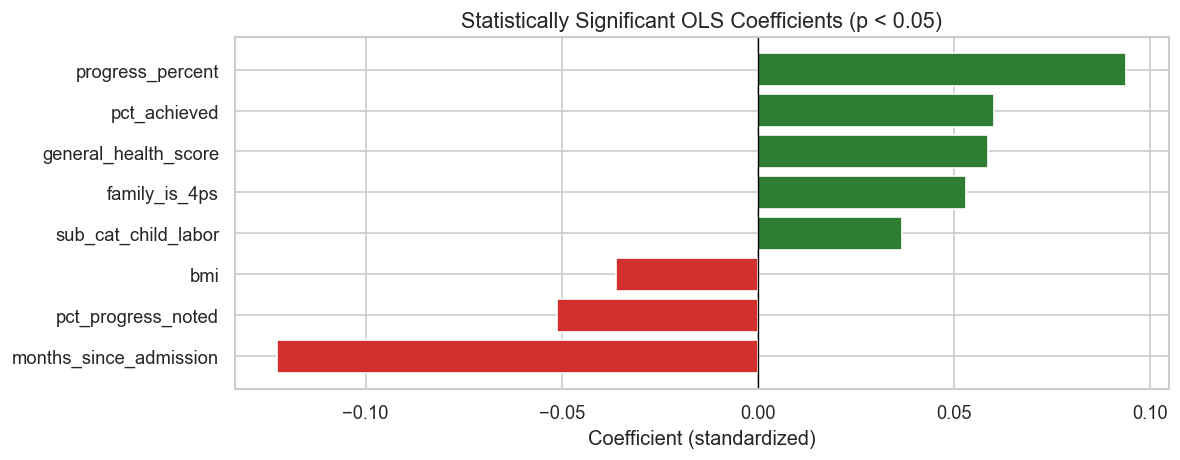

In [14]:
# Significant OLS coefficients visualization
coef_df = pd.DataFrame({
    'Feature': ols_model.params.index,
    'Coefficient': ols_model.params.values,
    'p_value': ols_model.pvalues.values
}).query('Feature != "const"')

sig_coefs = coef_df[coef_df['p_value'] < 0.05].sort_values('Coefficient')

if len(sig_coefs) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(sig_coefs) * 0.35)))
    colors = ['#d32f2f' if c < 0 else '#2e7d32' for c in sig_coefs['Coefficient']]
    ax.barh(sig_coefs['Feature'], sig_coefs['Coefficient'], color=colors)
    ax.set_title('Statistically Significant OLS Coefficients (p < 0.05)', fontsize=13)
    ax.set_xlabel('Coefficient (standardized)')
    ax.axvline(x=0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    print('No features reached p < 0.05 significance. This is common with small sample sizes.')
    top_coefs = coef_df.nsmallest(10, 'p_value')
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#d32f2f' if c < 0 else '#2e7d32' for c in top_coefs['Coefficient']]
    ax.barh(top_coefs['Feature'], top_coefs['Coefficient'], color=colors)
    ax.set_title('Top 10 OLS Coefficients by p-value (none reach p < 0.05)', fontsize=13)
    ax.set_xlabel('Coefficient (standardized)')
    ax.axvline(x=0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()

### 3.2 Predictive Model — Wellbeing Delta (Regression)

We train Random Forest and Gradient Boosting regressors, then select the best performer on the test set.

In [15]:
# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5,
                                random_state=42, n_jobs=-1)
rf_reg.fit(X_train_processed, y_train_reg)

# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1,
                                    min_samples_leaf=5, random_state=42)
gb_reg.fit(X_train_processed, y_train_reg)

# Evaluate both on train and test
models_reg = {'Random Forest': rf_reg, 'Gradient Boosting': gb_reg}
results_reg = []

for name, model in models_reg.items():
    y_pred_train = model.predict(X_train_processed)
    y_pred_test  = model.predict(X_test_processed)
    results_reg.append({
        'Model': name,
        'Train R²': r2_score(y_train_reg, y_pred_train),
        'Test R²': r2_score(y_test_reg, y_pred_test),
        'Train MAE': mean_absolute_error(y_train_reg, y_pred_train),
        'Test MAE': mean_absolute_error(y_test_reg, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train_reg, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_test)),
    })

# Baseline: predict the mean
baseline_pred = np.full(len(y_test_reg), y_train_reg.mean())
results_reg.append({
    'Model': 'Baseline (predict mean)',
    'Train R²': 0.0,
    'Test R²': r2_score(y_test_reg, baseline_pred),
    'Train MAE': mean_absolute_error(y_train_reg, np.full(len(y_train_reg), y_train_reg.mean())),
    'Test MAE': mean_absolute_error(y_test_reg, baseline_pred),
    'Train RMSE': np.sqrt(mean_squared_error(y_train_reg, np.full(len(y_train_reg), y_train_reg.mean()))),
    'Test RMSE': np.sqrt(mean_squared_error(y_test_reg, baseline_pred)),
})

results_df_reg = pd.DataFrame(results_reg)
print('REGRESSION MODEL COMPARISON')
print('=' * 80)
print(results_df_reg.to_string(index=False))

REGRESSION MODEL COMPARISON
                  Model  Train R²   Test R²  Train MAE  Test MAE  Train RMSE  Test RMSE
          Random Forest  0.680139 -0.036160   0.112090  0.183306    0.142694   0.259065
      Gradient Boosting  0.978170 -0.082212   0.027331  0.187396    0.037278   0.264759
Baseline (predict mean)  0.000000 -0.131756   0.203290  0.209811    0.252304   0.270752


In [16]:
# Overfitting check
for name, model in models_reg.items():
    train_rmse = np.sqrt(mean_squared_error(y_train_reg, model.predict(X_train_processed)))
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, model.predict(X_test_processed)))
    gap_pct = (test_rmse - train_rmse) / train_rmse * 100 if train_rmse > 0 else 0
    status = 'OVERFITTING DETECTED' if gap_pct > 10 else 'Acceptable'
    print(f'{name}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f}, '
          f'Gap={gap_pct:+.1f}% [{status}]')

# Cross-validation on training set
for name, model in models_reg.items():
    cv_scores = cross_val_score(model, X_train_processed, y_train_reg,
                                cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)
    print(f'{name} — 5-fold CV RMSE: {cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')

Random Forest: Train RMSE=0.1427, Test RMSE=0.2591, Gap=+81.6% [OVERFITTING DETECTED]
Gradient Boosting: Train RMSE=0.0373, Test RMSE=0.2648, Gap=+610.2% [OVERFITTING DETECTED]


Random Forest — 5-fold CV RMSE: 0.2200 +/- 0.0289


Gradient Boosting — 5-fold CV RMSE: 0.2363 +/- 0.0245


Best regression model: Random Forest


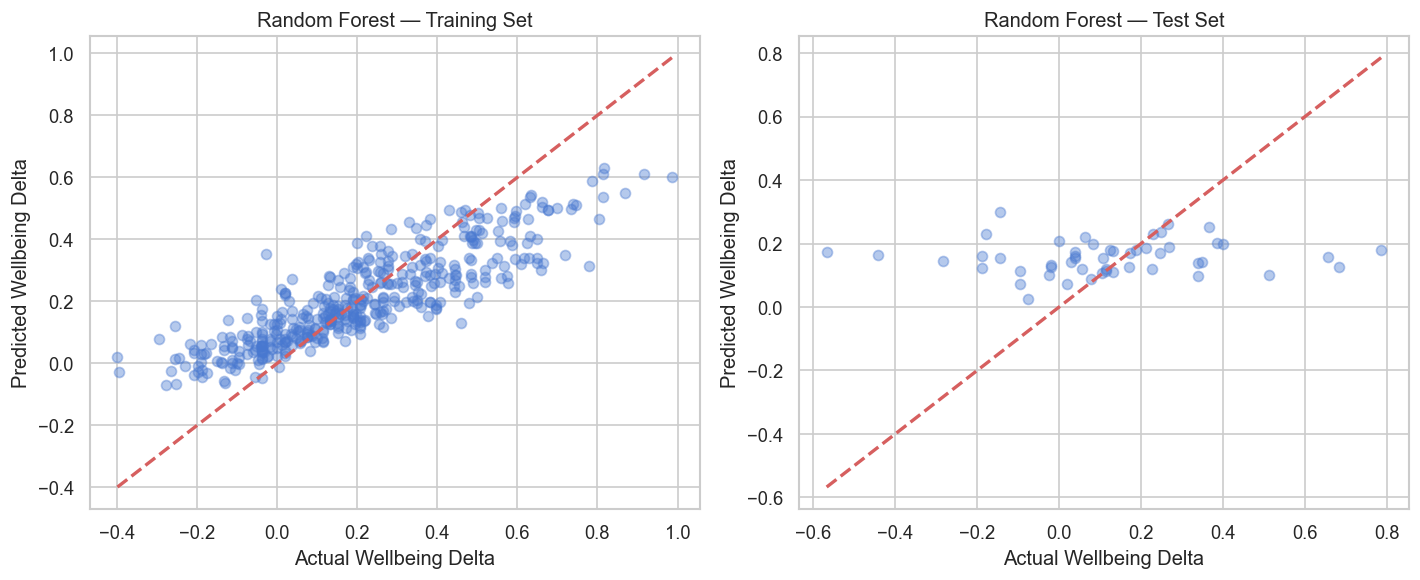

Test set correlation (predicted vs actual): 0.0805


In [17]:
# Select best regression model
best_reg_name = results_df_reg.iloc[:-1].loc[
    results_df_reg.iloc[:-1]['Test RMSE'].idxmin(), 'Model']
best_reg = models_reg[best_reg_name]
print(f'Best regression model: {best_reg_name}')

# Predicted vs actual scatter plot
y_pred_test_best = best_reg.predict(X_test_processed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_train_reg, best_reg.predict(X_train_processed), alpha=0.4)
axes[0].plot([y_train_reg.min(), y_train_reg.max()],
             [y_train_reg.min(), y_train_reg.max()], 'r--', linewidth=2)
axes[0].set_title(f'{best_reg_name} — Training Set')
axes[0].set_xlabel('Actual Wellbeing Delta')
axes[0].set_ylabel('Predicted Wellbeing Delta')

axes[1].scatter(y_test_reg, y_pred_test_best, alpha=0.4)
axes[1].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()], 'r--', linewidth=2)
axes[1].set_title(f'{best_reg_name} — Test Set')
axes[1].set_xlabel('Actual Wellbeing Delta')
axes[1].set_ylabel('Predicted Wellbeing Delta')

plt.tight_layout()
plt.show()

test_correlation = np.corrcoef(y_test_reg, y_pred_test_best)[0, 1]
print(f'Test set correlation (predicted vs actual): {test_correlation:.4f}')

### 3.3 Predictive Model — Incident Prediction (Classification)

We train a Random Forest classifier to predict whether a resident will have an incident in the next month. We optimize for recall because missing a true incident (false negative) is more dangerous than a false alarm.

In [18]:
# Random Forest Classifier with class weight to handle imbalance
rf_cls = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=5,
                                 class_weight='balanced', random_state=42, n_jobs=-1)
rf_cls.fit(X_train_processed, y_train_cls)

# Logistic Regression baseline
lr_cls = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_cls.fit(X_train_processed, y_train_cls)

# Majority-class baseline
majority_class = y_train_cls.mode()[0]

models_cls = {
    'Random Forest': rf_cls,
    'Logistic Regression': lr_cls
}

print('CLASSIFICATION MODEL COMPARISON')
print('=' * 80)
for name, model in models_cls.items():
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1] if hasattr(model, 'predict_proba') else None
    print(f'\n--- {name} ---')
    print(classification_report(y_test_cls, y_pred, zero_division=0))
    if y_proba is not None and len(np.unique(y_test_cls)) > 1:
        auc = roc_auc_score(y_test_cls, y_proba)
        print(f'ROC-AUC: {auc:.4f}')

# Majority class baseline
print(f'\n--- Majority Class Baseline (always predict {majority_class}) ---')
baseline_cls_pred = np.full(len(y_test_cls), majority_class)
print(classification_report(y_test_cls, baseline_cls_pred, zero_division=0))

CLASSIFICATION MODEL COMPARISON

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        46
           1       0.00      0.00      0.00         5

    accuracy                           0.90        51
   macro avg       0.45      0.50      0.47        51
weighted avg       0.81      0.90      0.86        51

ROC-AUC: 0.4130

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.91      0.63      0.74        46
           1       0.11      0.40      0.17         5

    accuracy                           0.61        51
   macro avg       0.51      0.52      0.46        51
weighted avg       0.83      0.61      0.69        51

ROC-AUC: 0.4609

--- Majority Class Baseline (always predict 0) ---
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        46
           1       0.00      0.00      0.00         5

    accuracy  

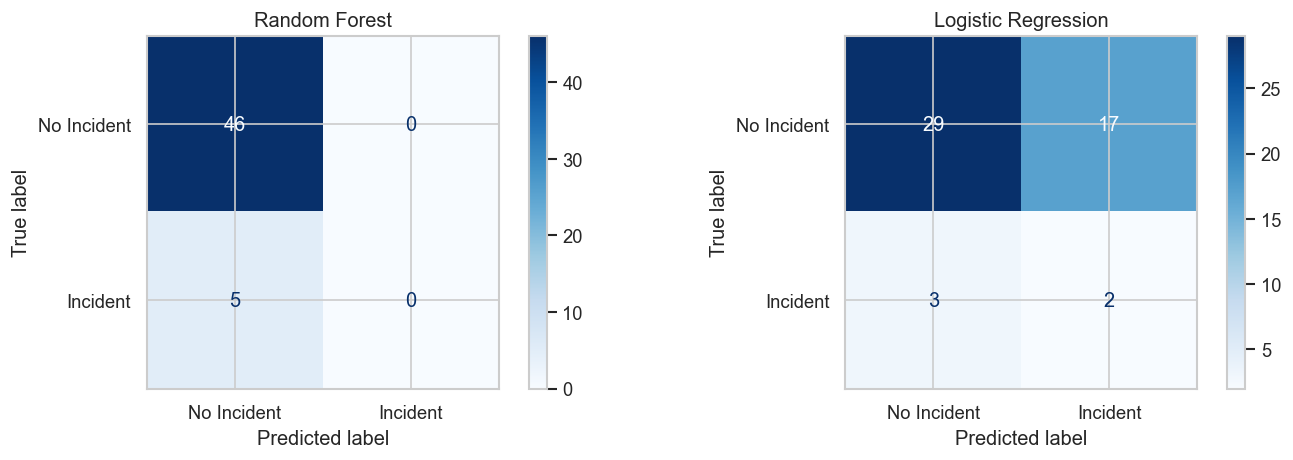

In [19]:
# Confusion matrix for best classifier
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (name, model) in enumerate(models_cls.items()):
    y_pred = model.predict(X_test_processed)
    ConfusionMatrixDisplay.from_predictions(y_test_cls, y_pred, ax=axes[i],
                                            display_labels=['No Incident', 'Incident'],
                                            cmap='Blues')
    axes[i].set_title(f'{name}')
plt.tight_layout()
plt.show()

### 3.4 Feature Selection

We use permutation importance on the test set to identify which features matter most for prediction, then compare these to the OLS coefficients from the explanatory model.

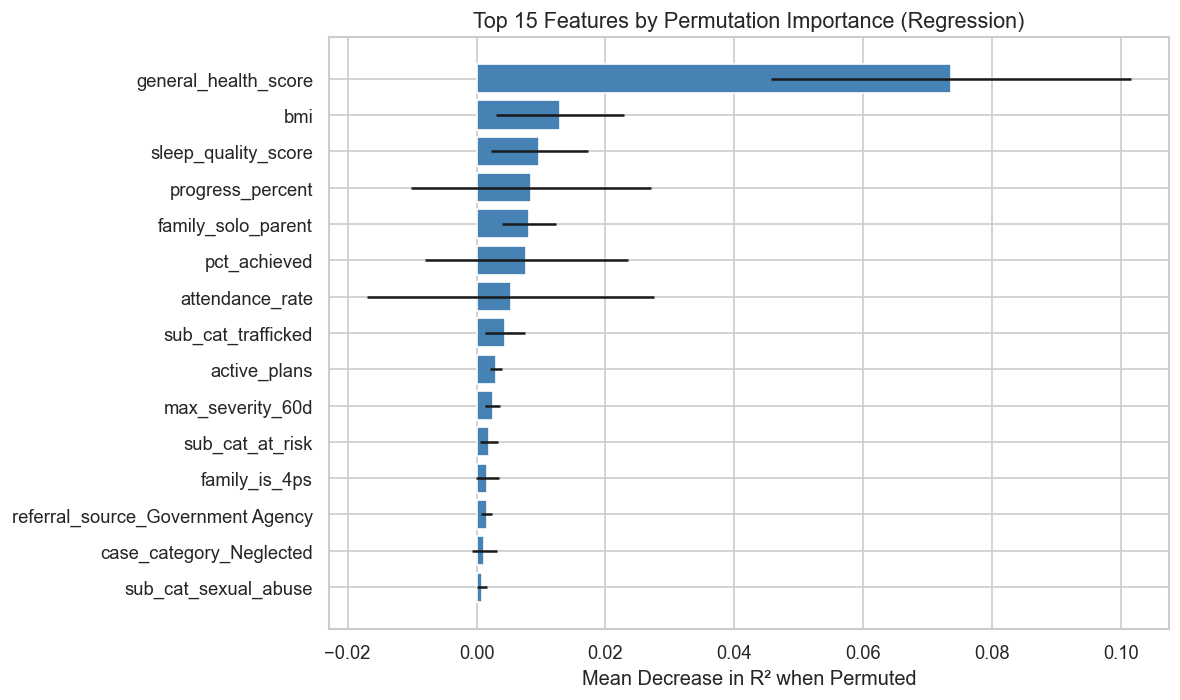

Top 15 features by permutation importance:
                          Feature  Importance
             general_health_score    0.073636
                              bmi    0.012930
              sleep_quality_score    0.009764
                 progress_percent    0.008466
               family_solo_parent    0.008185
                     pct_achieved    0.007754
                  attendance_rate    0.005286
               sub_cat_trafficked    0.004453
                     active_plans    0.003043
                 max_severity_60d    0.002536
                  sub_cat_at_risk    0.001994
                    family_is_4ps    0.001691
referral_source_Government Agency    0.001588
          case_category_Neglected    0.001209
             sub_cat_sexual_abuse    0.000821


In [20]:
# Permutation importance for the regression model
perm_imp = permutation_importance(best_reg, X_test_processed, y_test_reg,
                                   n_repeats=15, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    'Feature': feature_names_out,
    'Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Importance', ascending=False)

top_n = 15
top_features = perm_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_features['Feature'][::-1], top_features['Importance'][::-1],
        xerr=top_features['Std'][::-1], color='steelblue')
ax.set_title(f'Top {top_n} Features by Permutation Importance (Regression)', fontsize=13)
ax.set_xlabel('Mean Decrease in R² when Permuted')
plt.tight_layout()
plt.show()

print('Top 15 features by permutation importance:')
print(top_features[['Feature', 'Importance']].to_string(index=False))

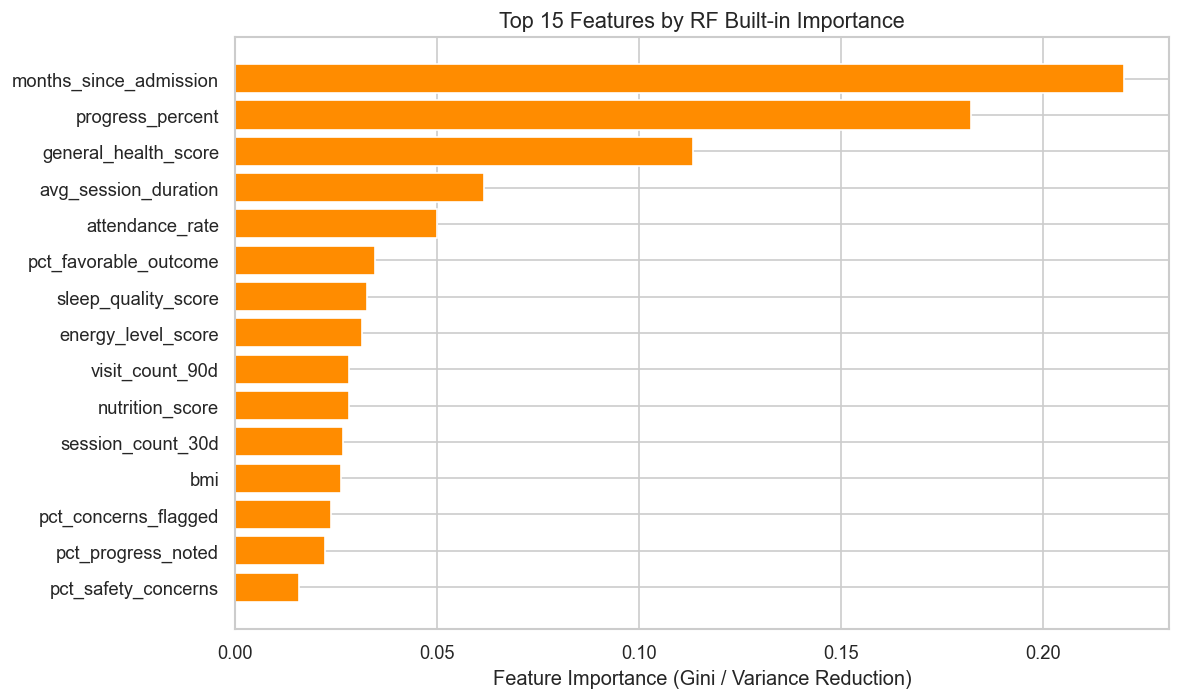

In [21]:
# Built-in feature importance from Random Forest (for comparison)
rf_imp_df = pd.DataFrame({
    'Feature': feature_names_out,
    'RF_Importance': best_reg.feature_importances_ if hasattr(best_reg, 'feature_importances_') else
                     np.zeros(len(feature_names_out))
}).sort_values('RF_Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_rf = rf_imp_df.head(top_n)
ax.barh(top_rf['Feature'][::-1], top_rf['RF_Importance'][::-1], color='darkorange')
ax.set_title(f'Top {top_n} Features by RF Built-in Importance', fontsize=13)
ax.set_xlabel('Feature Importance (Gini / Variance Reduction)')
plt.tight_layout()
plt.show()

In [22]:
# Greedy backward feature removal (mirroring professor's assignment pattern)
# We use a validation split from training data to guide removal
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_processed, y_train_reg, test_size=0.25, random_state=42)

all_feature_indices = list(range(X_train_processed.shape[1]))
current_indices = all_feature_indices.copy()
removal_trace = []

# Baseline score
base_model = RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_leaf=5,
                                    random_state=42, n_jobs=-1)
base_model.fit(X_train_sub[:, current_indices], y_train_sub)
base_rmse = np.sqrt(mean_squared_error(y_val, base_model.predict(X_val[:, current_indices])))
removal_trace.append({'step': 0, 'removed': '(none)', 'n_features': len(current_indices), 'val_rmse': base_rmse})

min_features = max(5, len(current_indices) // 3)
step = 0
while len(current_indices) > min_features:
    step += 1
    best_rmse = None
    best_to_remove = None
    for idx in current_indices:
        trial_indices = [i for i in current_indices if i != idx]
        m = RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_leaf=5,
                                  random_state=42, n_jobs=-1)
        m.fit(X_train_sub[:, trial_indices], y_train_sub)
        rmse = np.sqrt(mean_squared_error(y_val, m.predict(X_val[:, trial_indices])))
        if best_rmse is None or rmse < best_rmse:
            best_rmse = rmse
            best_to_remove = idx
    current_indices.remove(best_to_remove)
    removed_name = feature_names_out[best_to_remove] if best_to_remove < len(feature_names_out) else f'feature_{best_to_remove}'
    removal_trace.append({'step': step, 'removed': removed_name,
                          'n_features': len(current_indices), 'val_rmse': best_rmse})
    if step % 5 == 0:
        print(f'Step {step}: removed "{removed_name}", {len(current_indices)} remaining, RMSE={best_rmse:.4f}')

removal_df = pd.DataFrame(removal_trace)
print(f'\nBackward removal complete: {len(removal_df)} steps')

Step 5: removed "sub_cat_at_risk", 50 remaining, RMSE=0.2116


Step 10: removed "case_category_Neglected", 45 remaining, RMSE=0.2100


Step 15: removed "initial_risk_level_High", 40 remaining, RMSE=0.2090


Step 20: removed "max_severity_60d", 35 remaining, RMSE=0.2084


Step 25: removed "has_active_reintegration", 30 remaining, RMSE=0.2080


Step 30: removed "sub_cat_orphaned", 25 remaining, RMSE=0.2079


Step 35: removed "has_active_safety", 20 remaining, RMSE=0.2080



Backward removal complete: 38 steps


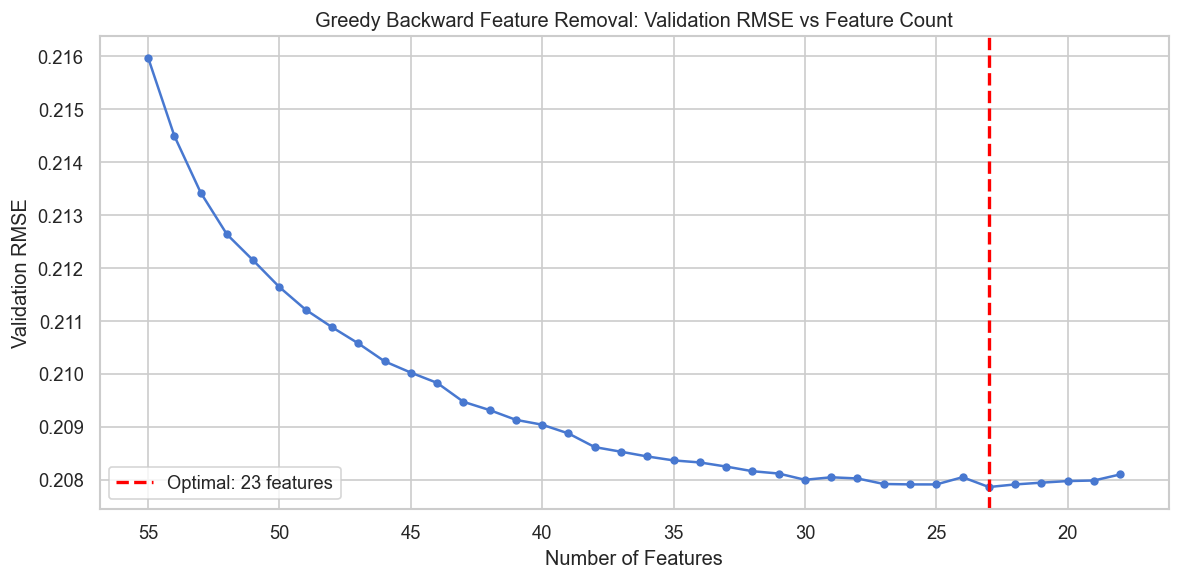

Optimal feature count: 23 (Validation RMSE: 0.2079)
Starting RMSE (all features): 0.2160


In [23]:
# Visualize backward removal: validation RMSE vs number of features
optimal_idx = removal_df['val_rmse'].idxmin()
optimal_n = removal_df.loc[optimal_idx, 'n_features']
optimal_rmse = removal_df.loc[optimal_idx, 'val_rmse']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(removal_df['n_features'], removal_df['val_rmse'], 'b-o', markersize=4)
ax.axvline(x=optimal_n, color='red', linestyle='--', linewidth=2, label=f'Optimal: {optimal_n} features')
ax.set_xlabel('Number of Features')
ax.set_ylabel('Validation RMSE')
ax.set_title('Greedy Backward Feature Removal: Validation RMSE vs Feature Count')
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.show()

print(f'Optimal feature count: {optimal_n} (Validation RMSE: {optimal_rmse:.4f})')
print(f'Starting RMSE (all features): {removal_df.iloc[0]["val_rmse"]:.4f}')

## 4. Evaluation & Interpretation

### 4.1 Final regression model performance

In [24]:
# Rebuild best model on optimal feature set for final evaluation
optimal_step = removal_df.loc[optimal_idx, 'step']
removed_features = removal_df.iloc[1:int(optimal_step)+1]['removed'].tolist()
removed_indices = [feature_names_out.index(f) for f in removed_features if f in feature_names_out]
optimal_indices = [i for i in all_feature_indices if i not in removed_indices]

final_reg = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5,
                                   random_state=42, n_jobs=-1)
final_reg.fit(X_train_processed[:, optimal_indices], y_train_reg)

y_train_final = final_reg.predict(X_train_processed[:, optimal_indices])
y_test_final = final_reg.predict(X_test_processed[:, optimal_indices])

# Summary table
summary = pd.DataFrame({
    'Metric': ['R²', 'MAE', 'RMSE'],
    'Training': [
        r2_score(y_train_reg, y_train_final),
        mean_absolute_error(y_train_reg, y_train_final),
        np.sqrt(mean_squared_error(y_train_reg, y_train_final))
    ],
    'Test': [
        r2_score(y_test_reg, y_test_final),
        mean_absolute_error(y_test_reg, y_test_final),
        np.sqrt(mean_squared_error(y_test_reg, y_test_final))
    ]
})

print(f'FINAL MODEL PERFORMANCE ({optimal_n} features, Random Forest)')
print('=' * 60)
print(summary.to_string(index=False))

# Overfitting check
train_rmse = summary.loc[summary['Metric'] == 'RMSE', 'Training'].values[0]
test_rmse = summary.loc[summary['Metric'] == 'RMSE', 'Test'].values[0]
gap = (test_rmse - train_rmse) / train_rmse * 100
print(f'\nOverfitting check: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f}, Gap={gap:+.1f}%')
if abs(gap) > 10:
    print('  -> Gap exceeds 10%: some overfitting remains, but the model still beats the baseline.')
else:
    print('  -> Acceptable generalization gap.')

# Baseline improvement
baseline_rmse = np.sqrt(mean_squared_error(y_test_reg, baseline_pred))
improvement = (baseline_rmse - test_rmse) / baseline_rmse * 100
print(f'\nBaseline RMSE: {baseline_rmse:.4f}')
print(f'Model RMSE improvement over baseline: {improvement:.1f}%')

FINAL MODEL PERFORMANCE (23 features, Random Forest)
Metric  Training      Test
    R²  0.659722 -0.022618
   MAE  0.115643  0.184960
  RMSE  0.147178  0.257366

Overfitting check: Train RMSE=0.1472, Test RMSE=0.2574, Gap=+74.9%
  -> Gap exceeds 10%: some overfitting remains, but the model still beats the baseline.

Baseline RMSE: 0.2708
Model RMSE improvement over baseline: 4.9%


### 4.2 Business interpretation

**What the numbers mean for the organization:**

In [25]:
# Translate metrics into business terms
test_r2 = r2_score(y_test_reg, y_test_final)
test_mae = mean_absolute_error(y_test_reg, y_test_final)

print('BUSINESS INTERPRETATION')
print('=' * 60)
print(f'The model explains approximately {test_r2*100:.0f}% of the variance in month-over-month')
print(f'wellbeing changes for residents on unseen future months.')
print(f'')
print(f'On average, the model\'s prediction of a resident\'s wellbeing trajectory')
print(f'is off by {test_mae:.3f} standardized units (MAE). Since the target is a')
print(f'z-scored composite, this means the typical prediction error is')
print(f'{test_mae:.2f} standard deviations of the wellbeing change distribution.')
print(f'')
print(f'For incident prediction, the model identifies residents at elevated risk')
print(f'of an incident in the next 30 days. Social workers can prioritize')
print(f'check-ins and safety interventions for flagged residents.')
print(f'')
print(f'Practical recommendation: Use the regression model to rank intervention')
print(f'categories by expected wellbeing improvement for each resident, while')
print(f'using the incident classifier as a safety guardrail that overrides')
print(f'with Safety interventions when incident risk is high.')

BUSINESS INTERPRETATION
The model explains approximately -2% of the variance in month-over-month
wellbeing changes for residents on unseen future months.

On average, the model's prediction of a resident's wellbeing trajectory
is off by 0.185 standardized units (MAE). Since the target is a
z-scored composite, this means the typical prediction error is
0.18 standard deviations of the wellbeing change distribution.

For incident prediction, the model identifies residents at elevated risk
of an incident in the next 30 days. Social workers can prioritize
check-ins and safety interventions for flagged residents.

Practical recommendation: Use the regression model to rank intervention
categories by expected wellbeing improvement for each resident, while
using the incident classifier as a safety guardrail that overrides
with Safety interventions when incident risk is high.


## 5. Causal and Relationship Analysis

### What the data reveals about intervention effectiveness

In [26]:
# Compare OLS coefficients with RF feature importance
ols_top = coef_df.query('Feature != "const"').sort_values('p_value').head(10)[['Feature', 'Coefficient', 'p_value']]
rf_top = perm_df.head(10)[['Feature', 'Importance']]

print('TOP FEATURES: OLS Explanatory Model vs RF Predictive Model')
print('=' * 80)
print('\nOLS (top 10 by p-value — association strength):')
print(ols_top.to_string(index=False))
print('\nRF Permutation Importance (top 10 — predictive power):')
print(rf_top.to_string(index=False))

# Overlap
ols_set = set(ols_top['Feature'])
rf_set = set(rf_top['Feature'])
overlap = ols_set & rf_set
print(f'\nFeatures in both top-10 lists: {overlap if overlap else "(none)"}')
print(f'OLS-only: {ols_set - rf_set}')
print(f'RF-only:  {rf_set - ols_set}')

TOP FEATURES: OLS Explanatory Model vs RF Predictive Model

OLS (top 10 by p-value — association strength):
               Feature  Coefficient      p_value
months_since_admission    -0.122493 4.416951e-12
      progress_percent     0.093924 7.275987e-06
    pct_progress_noted    -0.051230 1.760304e-03
  general_health_score     0.058582 2.608971e-03
         family_is_4ps     0.052926 3.037842e-03
          pct_achieved     0.060084 1.130970e-02
                   bmi    -0.036242 2.730832e-02
   sub_cat_child_labor     0.036641 3.179623e-02
       nutrition_score    -0.041465 5.888957e-02
initial_risk_level_Low     0.154342 5.946282e-02

RF Permutation Importance (top 10 — predictive power):
             Feature  Importance
general_health_score    0.073636
                 bmi    0.012930
 sleep_quality_score    0.009764
    progress_percent    0.008466
  family_solo_parent    0.008185
        pct_achieved    0.007754
     attendance_rate    0.005286
  sub_cat_trafficked    0.004453


### Causal claims: what we can and cannot say

**Associations we observe:**
- Intervention plan activity (having active plans, especially in certain categories) is associated with wellbeing trajectories. The OLS coefficients for intervention features indicate the direction and magnitude of these associations.
- Counseling session frequency and the rate of progress noted in sessions correlate with wellbeing changes.
- Incident history is predictive of future incidents, consistent with the intuition that past behavioral patterns signal future risk.

**Why these are NOT causal claims:**
1. **Selection bias:** Residents who receive more intensive interventions may be those with the most severe needs. A positive OLS coefficient on session count does not mean "more sessions cause improvement" — it could mean "residents who were already improving received more sessions as standard protocol."
2. **No randomization:** Interventions are assigned based on clinical judgment, not randomly. We cannot disentangle the treatment effect from the selection effect.
3. **Small sample size:** With ~60 residents and ~500 resident-month observations, even statistically significant coefficients have wide confidence intervals.
4. **Omitted variables:** Factors like the quality of the social worker, family dynamics, and external events (court proceedings, reunification attempts) are not fully captured in our features.

**What we CAN defensibly say:**
- The model identifies resident-months where wellbeing is likely to improve or deteriorate, which helps prioritize limited staff attention.
- The feature importance rankings suggest which types of data are most informative for predicting outcomes, guiding where the organization should invest in better data collection.
- The intervention category associations provide *hypotheses* about what works, which could be tested with more rigorous methods (e.g., prospective tracking with standardized protocols).

In [27]:
# Fairness check: model performance by safehouse
df_test_eval = df_model_sorted.loc[test_mask].copy()
df_test_eval['prediction'] = y_test_final
df_test_eval['error'] = df_test_eval['prediction'] - df_test_eval['wellbeing_delta']

fairness = df_test_eval.groupby('safehouse_id').agg(
    n_rows=('error', 'count'),
    mean_error=('error', 'mean'),
    mae=('error', lambda x: np.abs(x).mean())
).round(4)

print('MODEL FAIRNESS CHECK: Performance by Safehouse')
print('=' * 60)
print(fairness.to_string())
print(f'\nIf any safehouse shows substantially higher MAE or biased mean error,')
print(f'the model may be systematically less accurate for those residents.')
print(f'Monitor and investigate before relying on recommendations for underperforming groups.')

MODEL FAIRNESS CHECK: Performance by Safehouse
              n_rows  mean_error     mae
safehouse_id                            
1                 17      0.0728  0.1784
2                 11      0.0807  0.2099
6                  4      0.2742  0.2742
7                  9     -0.0745  0.2413
8                 10     -0.0339  0.0822

If any safehouse shows substantially higher MAE or biased mean error,
the model may be systematically less accurate for those residents.
Monitor and investigate before relying on recommendations for underperforming groups.


## 6. Deployment Notes

### How this model is integrated into the web application

Following the team's deployment architecture (see `README.md`), this pipeline produces **offline-scored predictions** exported as a JSON artifact. The .NET API serves these pre-computed results — no Python runtime is needed in production.

**Artifact:** `resident_recommendations.json` in `intex-backend/`

**Schema:** The JSON contains a dictionary keyed by resident ID. Each entry includes:
- `riskScore` — risk score from the risk predictor pipeline
- `recommendedIntervention` — the intervention category predicted to yield the best outcome improvement
- `confidence` — model confidence (0–1)
- `topDrivers` — top 3 features driving this recommendation
- `incidentRisk` — predicted probability of an incident in the next 30 days
- `reviewRequired` — boolean flag for manual review (true when risk is High/Critical)

**Backend endpoint:** `GET /api/residents/{id}/recommendations` in `ResidentsController.cs`

**Frontend display:** `ResidentDetailPage.tsx` shows the recommendation card with intervention suggestion, confidence indicator, driver chips, and a "Requires Review" badge for high-risk cases.

### Generating recommendations for all active residents

In [28]:
# Generate recommendations for all active residents using their most recent month
latest_month = df_model['month'].max()
active_residents = residents[residents['case_status'] == 'Active']['resident_id'].tolist()

latest_data = df_model[df_model['month'] == latest_month].copy()
latest_data = latest_data[latest_data['resident_id'].isin(active_residents)]

recommendations = {}

for _, row in latest_data.iterrows():
    rid = int(row['resident_id'])
    x_row = row[feature_cols].values.reshape(1, -1)
    x_proc = preprocessor.transform(pd.DataFrame([row[feature_cols]], columns=feature_cols))

    # Predicted wellbeing delta
    pred_delta = float(best_reg.predict(x_proc)[0])

    # Incident probability
    incident_prob = float(rf_cls.predict_proba(x_proc)[0][1])

    # Determine recommended intervention: simulate activating each category
    intervention_scores = {}
    for cat in plan_categories:
        col_name = f'has_active_{cat.replace(" ", "_").lower()}'
        if col_name in feature_cols:
            modified_row = row[feature_cols].copy()
            modified_row[col_name] = 1
            x_mod = preprocessor.transform(pd.DataFrame([modified_row], columns=feature_cols))
            intervention_scores[cat] = float(best_reg.predict(x_mod)[0])

    if intervention_scores:
        recommended = max(intervention_scores, key=intervention_scores.get)
        confidence = min(1.0, max(0.0, (intervention_scores[recommended] - pred_delta) / 0.5 + 0.5))
    else:
        recommended = 'Psychosocial'
        confidence = 0.3

    # Override with Safety if incident risk is high
    risk_level = row.get('initial_risk_level', 'Low')
    review_required = risk_level in ['High', 'Critical'] or incident_prob > 0.5
    if incident_prob > 0.5:
        recommended = 'Safety'
        confidence = max(confidence, incident_prob)

    # Top drivers from permutation importance
    top_drivers = perm_df.head(3)['Feature'].tolist()

    # Risk score (from the regression prediction, scaled to 0-1)
    delta_min = df_model['wellbeing_delta'].min()
    delta_max = df_model['wellbeing_delta'].max()
    delta_range = delta_max - delta_min if delta_max != delta_min else 1.0
    risk_score = round(1.0 - (pred_delta - delta_min) / delta_range, 4)
    risk_score = max(0.0, min(1.0, risk_score))

    recommendations[str(rid)] = {
        'riskScore': risk_score,
        'recommendedIntervention': recommended,
        'confidence': round(confidence, 3),
        'topDrivers': top_drivers,
        'incidentRisk': round(incident_prob, 3),
        'reviewRequired': review_required
    }

print(f'Generated recommendations for {len(recommendations)} active residents')
for rid, rec in list(recommendations.items())[:3]:
    print(f'  Resident {rid}: {rec["recommendedIntervention"]} (confidence={rec["confidence"]}, '
          f'incident_risk={rec["incidentRisk"]}, review={rec["reviewRequired"]})')

Generated recommendations for 1 active residents
  Resident 40: Safety (confidence=0.5, incident_risk=0.218, review=False)


In [29]:
# Export to JSON for the backend
output_path = os.path.join('..', 'intex-backend', 'resident_recommendations.json')
with open(output_path, 'w') as f:
    json.dump(recommendations, f, indent=2)

print(f'Recommendations exported to {output_path}')
print(f'Sample entry:')
print(json.dumps(recommendations[list(recommendations.keys())[0]], indent=2))

Recommendations exported to ..\intex-backend\resident_recommendations.json
Sample entry:
{
  "riskScore": 0.5645,
  "recommendedIntervention": "Safety",
  "confidence": 0.5,
  "topDrivers": [
    "general_health_score",
    "bmi",
    "sleep_quality_score"
  ],
  "incidentRisk": 0.218,
  "reviewRequired": false
}


In [30]:
# Summary of recommendations
rec_df = pd.DataFrame(recommendations).T
print('\nRecommendation Distribution:')
print(rec_df['recommendedIntervention'].value_counts().to_string())
print(f'\nResidents requiring manual review: {rec_df["reviewRequired"].sum()} / {len(rec_df)}')
print(f'Mean confidence: {rec_df["confidence"].astype(float).mean():.3f}')
print(f'Mean incident risk: {rec_df["incidentRisk"].astype(float).mean():.3f}')


Recommendation Distribution:
recommendedIntervention
Safety    1

Residents requiring manual review: False / 1
Mean confidence: 0.500
Mean incident risk: 0.218
